# Import Libraries

In [54]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")


# Data Loading

In [55]:
orders = pd.read_csv(r"C:\Users\urvas\Downloads\Customer segmentation\data\olist_orders_dataset.csv")
orders.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


# Data Cleaning and Preprocessing

In [56]:
orders.shape

(99441, 8)

In [57]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [58]:
orders.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-08-02 12:05:26,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 19:36:48,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [59]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

### Date Columns → Datetime Conversion

In [60]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col],errors='coerce')

In [61]:
orders[date_cols].head()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [62]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

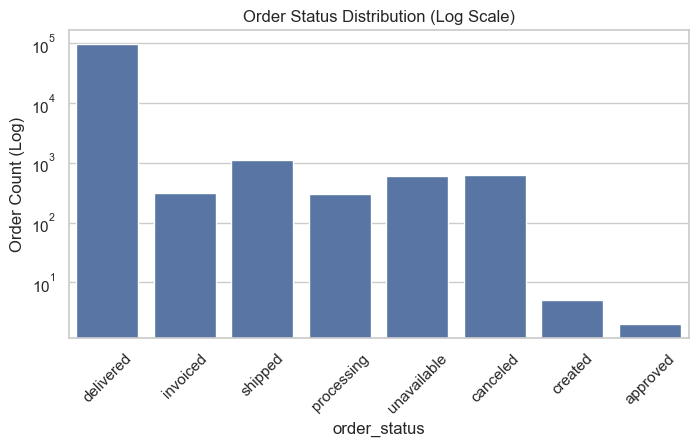

In [63]:
plt.figure(figsize=(8,4))
sns.countplot(data=orders, x='order_status')
plt.yscale('log')
plt.title("Order Status Distribution (Log Scale)")
plt.xticks(rotation=45)
plt.ylabel("Order Count (Log)")
plt.show()

In [64]:
delivered_orders = orders[orders['order_status'] == 'delivered']

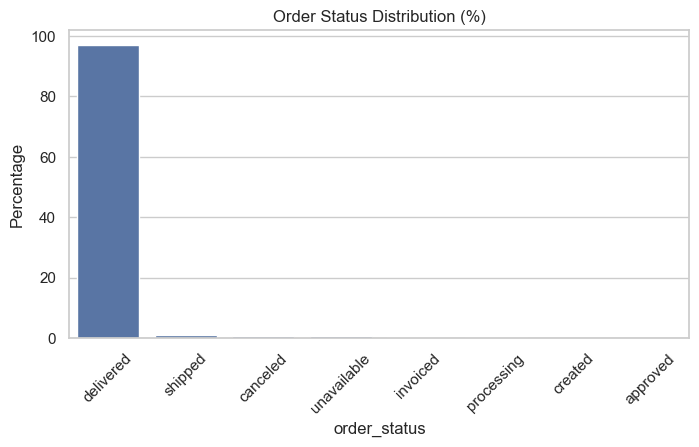

In [65]:
status_pct = orders['order_status'].value_counts(normalize=True) * 100
plt.figure(figsize=(8,4))
sns.barplot(x=status_pct.index, y=status_pct.values)
plt.title("Order Status Distribution (%)")
plt.xticks(rotation=45)
plt.ylabel("Percentage")
plt.show()

# Delivery Time Analysis

### A. Delivery Time(Days)

In [66]:
delivered_orders['delivery_time_days'] = (delivered_orders['order_delivered_customer_date'] - delivered_orders['order_purchase_timestamp']).dt.days

C:\Users\urvas\AppData\Local\Temp\ipykernel_34304\567928914.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivered_orders['delivery_time_days'] = (delivered_orders['order_delivered_customer_date'] - delivered_orders['order_purchase_timestamp']).dt.days


In [67]:
delivered_orders['delivery_time_days'].describe()

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_time_days, dtype: float64

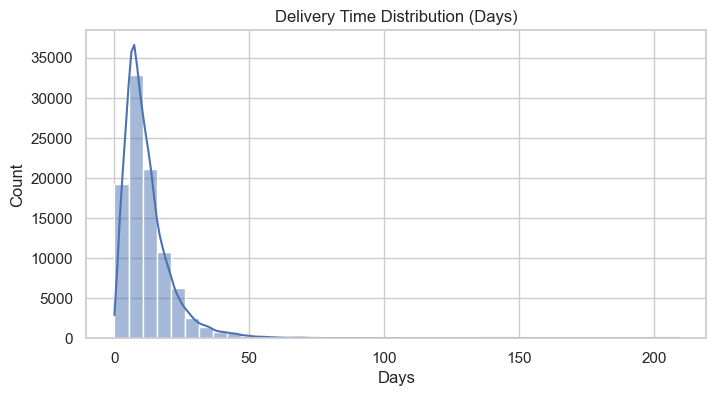

In [68]:
plt.figure(figsize=(8,4))
sns.histplot(delivered_orders['delivery_time_days'], bins=40, kde=True)
plt.title("Delivery Time Distribution (Days)")
plt.xlabel("Days")
plt.show()


### Estimated vs Actual Delivery

In [69]:
delivered_orders['estimated_vs_actual'] = (delivered_orders['order_estimated_delivery_date'] - delivered_orders['order_delivered_customer_date']).dt.days

C:\Users\urvas\AppData\Local\Temp\ipykernel_34304\3417861756.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivered_orders['estimated_vs_actual'] = (delivered_orders['order_estimated_delivery_date'] - delivered_orders['order_delivered_customer_date']).dt.days


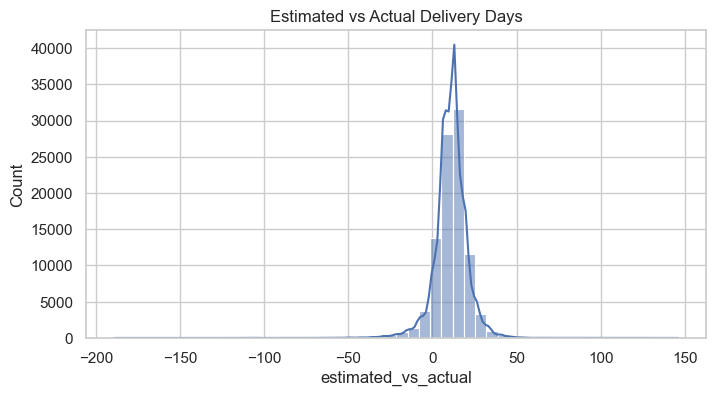

In [70]:
plt.figure(figsize=(8,4))
sns.histplot(delivered_orders['estimated_vs_actual'], bins=50, kde=True)
plt.title("Estimated vs Actual Delivery Days")
plt.show()

# Order Volume Over Time

### Orders per Month

In [71]:
delivered_orders['order_month'] = delivered_orders['order_purchase_timestamp'].dt.to_period('M')
orders_per_month = delivered_orders.groupby('order_month').size()

C:\Users\urvas\AppData\Local\Temp\ipykernel_34304\3183699569.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivered_orders['order_month'] = delivered_orders['order_purchase_timestamp'].dt.to_period('M')


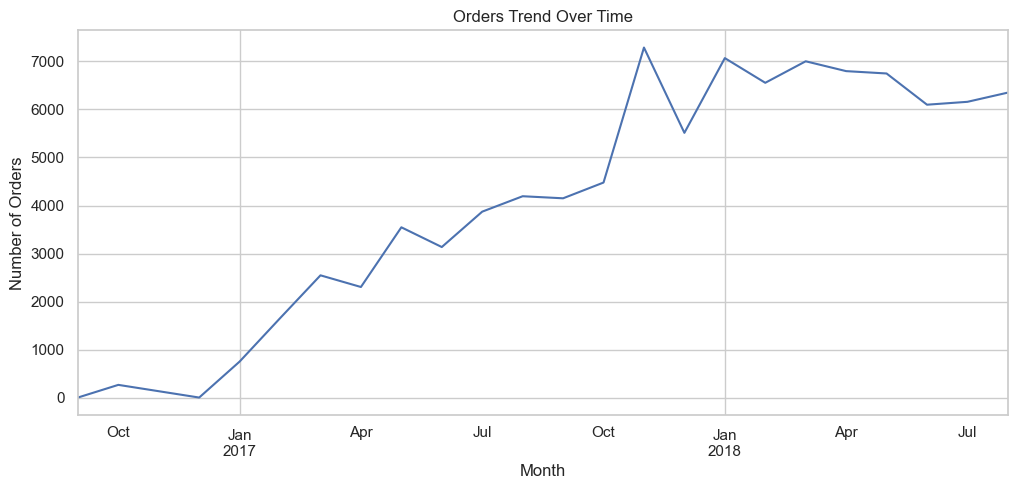

In [72]:
orders_per_month.plot(figsize=(12,5))
plt.title("Orders Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()

### Orders per Customer

In [73]:
orders_per_customer = delivered_orders.groupby('customer_id').size()
orders_per_customer.describe()

count    96478.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
dtype: float64

In [74]:
orders_per_customer.value_counts()

1    96478
Name: count, dtype: int64

# Save Dataset Orders

In [75]:
os.makedirs("processed", exist_ok=True)
delivered_orders.to_csv("processed/orders_clean.csv", index=False)